# Nvidia Capex-Based Owner Sanity Check

Cross-references estimated Nvidia GPU spending by Microsoft and Meta (using static allocation shares of Nvidia DC revenue) against their reported capex, as a plausibility check on the allocation estimates.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Consistent color scheme: green family = Microsoft, dark blue family = Meta
# Darker = static share, lighter = proposed varying share
MSFT_COLOR = '#107C10'
MSFT_ALT_COLOR = '#7FBA00'
META_COLOR = '#0D47A1'
META_ALT_COLOR = '#64B5F6'

## Data

In [17]:
# Allocation shares (as share of Nvidia DC revenue, based on analyst estimates from 2024-2025)
MSFT_DC_SHARE = 0.21
META_DC_SHARE = 0.11

# Meta proposed varying share trajectory (static for most quarters, then adjusted)
meta_proposed_shares = (
    [META_DC_SHARE] * 11  # FY23Q1 through FY25Q3
    + [0.13]       # FY25Q4
    + [0.13]       # FY26Q1
    + [0.13]       # FY26Q2
    + [0.12]       # FY26Q3
    + [0.12]       # FY26Q4
)

# Microsoft proposed varying share trajectory (static for first 11, then adjusted)
msft_proposed_shares = (
    [MSFT_DC_SHARE] * 11  # FY23Q1 through FY25Q3
    + [0.23]              # FY25Q4
    + [0.21]              # FY26Q1
    + [0.22]              # FY26Q2
    + [0.21]              # FY26Q3
    + [0.20]              # FY26Q4
)

df = pd.DataFrame({
    'quarter': ['FY23Q1', 'FY23Q2', 'FY23Q3', 'FY23Q4',
                'FY24Q1', 'FY24Q2', 'FY24Q3', 'FY24Q4',
                'FY25Q1', 'FY25Q2', 'FY25Q3', 'FY25Q4',
                'FY26Q1', 'FY26Q2', 'FY26Q3', 'FY26Q4'],
    'end_date': pd.to_datetime([
        '2022-05-01', '2022-07-31', '2022-10-30', '2023-01-29',
        '2023-04-30', '2023-07-30', '2023-10-29', '2024-01-28',
        '2024-04-28', '2024-07-28', '2024-10-27', '2025-01-26',
        '2025-04-27', '2025-07-27', '2025-10-26', '2026-01-26']),
    'nvidia_dc_revenue': [3.75, 3.81, 3.83, 3.62, 4.28, 10.32, 14.51, 18.40,
                          22.60, 26.30, 30.80, 35.60, 39.10, 41.10, 51.20, 62.30],
    'msft_quarter_end': pd.to_datetime([
        '2022-03-31', '2022-06-30', '2022-09-30', '2022-12-31',
        '2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31',
        '2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31',
        '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-31']),
    'msft_capex': [6.3, 8.7, 6.6, 6.8, 7.8, 10.7, 11.2, 11.5,
                   14.0, 19.0, 20.0, 22.6, 21.4, 24.2, 34.9, 37.5],
    'meta_quarter_end': pd.to_datetime([
        '2022-03-31', '2022-06-30', '2022-09-30', '2022-12-31',
        '2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31',
        '2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31',
        '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-31']),
    'meta_capex': [5.67, 7.79, 9.54, 9.28, 7.11, 6.44, 6.81, 7.97,
                   6.70, 8.47, 9.20, 14.80, 13.70, 17.01, 19.37, 22.10],
    'meta_proposed_share': meta_proposed_shares[:16],
    'msft_proposed_share': msft_proposed_shares[:16],
})

## Calculations

In [18]:
# --- Microsoft (static share) ---
df['msft_share'] = MSFT_DC_SHARE
df['msft_nvidia_spend'] = (MSFT_DC_SHARE * df['nvidia_dc_revenue']).round(2)
df['msft_nvidia_pct_capex'] = df['msft_nvidia_spend'] / df['msft_capex']
df['msft_nvidia_pct_capex_ttm'] = (
    df['msft_nvidia_spend'].rolling(4).sum() / df['msft_capex'].rolling(4).sum()
)

# --- Microsoft (proposed varying share) ---
df['msft_implied_spend'] = (df['msft_proposed_share'] * df['nvidia_dc_revenue']).round(3)
df['msft_alt_nvidia_pct_capex'] = df['msft_implied_spend'] / df['msft_capex']
df['msft_alt_nvidia_pct_capex_ttm'] = (
    df['msft_implied_spend'].rolling(4).sum() / df['msft_capex'].rolling(4).sum()
)

# --- Meta (static share) ---
df['meta_share'] = META_DC_SHARE
df['meta_nvidia_spend'] = (META_DC_SHARE * df['nvidia_dc_revenue']).round(2)
df['meta_nvidia_pct_capex'] = df['meta_nvidia_spend'] / df['meta_capex']
df['meta_nvidia_pct_capex_ttm'] = (
    df['meta_nvidia_spend'].rolling(4).sum() / df['meta_capex'].rolling(4).sum()
)

# --- Meta (proposed varying share) ---
df['meta_implied_spend'] = (df['meta_proposed_share'] * df['nvidia_dc_revenue']).round(3)
df['meta_alt_nvidia_pct_capex'] = df['meta_implied_spend'] / df['meta_capex']
df['meta_alt_nvidia_pct_capex_ttm'] = (
    df['meta_implied_spend'].rolling(4).sum() / df['meta_capex'].rolling(4).sum()
)

# --- Display with readable column names ---
display_df = df[[
    'quarter', 'nvidia_dc_revenue',
    'msft_share', 'msft_nvidia_spend', 'msft_capex', 'msft_nvidia_pct_capex', 'msft_nvidia_pct_capex_ttm',
    'msft_proposed_share', 'msft_implied_spend', 'msft_alt_nvidia_pct_capex', 'msft_alt_nvidia_pct_capex_ttm',
    'meta_share', 'meta_nvidia_spend', 'meta_capex', 'meta_nvidia_pct_capex', 'meta_nvidia_pct_capex_ttm',
    'meta_proposed_share', 'meta_implied_spend', 'meta_alt_nvidia_pct_capex', 'meta_alt_nvidia_pct_capex_ttm',
]].copy()

display_df.columns = [
    'Quarter', 'NVDA DC Rev ($B)',
    'MSFT Share of DC', 'MSFT NVDA Spend ($B)', 'MSFT Capex ($B)', 'MSFT NVDA/Capex', 'MSFT NVDA/Capex (TTM)',
    'MSFT Proposed Share', 'MSFT Implied Spend ($B)', 'MSFT NVDA/Capex (alt)', 'MSFT NVDA/Capex (TTM, alt)',
    'Meta Share of DC', 'Meta NVDA Spend ($B)', 'Meta Capex ($B)', 'Meta NVDA/Capex', 'Meta NVDA/Capex (TTM)',
    'Meta Proposed Share', 'Meta Implied Spend ($B)', 'Meta NVDA/Capex (alt)', 'Meta NVDA/Capex (TTM, alt)',
]

display_df.style.format({
    'NVDA DC Rev ($B)': '${:.2f}',
    'MSFT Share of DC': '{:.1%}', 'MSFT NVDA Spend ($B)': '${:.2f}', 'MSFT Capex ($B)': '${:.1f}',
    'MSFT NVDA/Capex': '{:.1%}', 'MSFT NVDA/Capex (TTM)': '{:.1%}',
    'MSFT Proposed Share': '{:.1%}', 'MSFT Implied Spend ($B)': '${:.2f}',
    'MSFT NVDA/Capex (alt)': '{:.1%}', 'MSFT NVDA/Capex (TTM, alt)': '{:.1%}',
    'Meta Share of DC': '{:.1%}', 'Meta NVDA Spend ($B)': '${:.2f}', 'Meta Capex ($B)': '${:.1f}',
    'Meta NVDA/Capex': '{:.1%}', 'Meta NVDA/Capex (TTM)': '{:.1%}',
    'Meta Proposed Share': '{:.1%}', 'Meta Implied Spend ($B)': '${:.2f}',
    'Meta NVDA/Capex (alt)': '{:.1%}', 'Meta NVDA/Capex (TTM, alt)': '{:.1%}',
})

,Quarter,NVDA DC Rev ($B),MSFT Share of DC,MSFT NVDA Spend ($B),MSFT Capex ($B),MSFT NVDA/Capex,MSFT NVDA/Capex (TTM),MSFT Proposed Share,MSFT Implied Spend ($B),MSFT NVDA/Capex (alt),"MSFT NVDA/Capex (TTM, alt)",Meta Share of DC,Meta NVDA Spend ($B),Meta Capex ($B),Meta NVDA/Capex,Meta NVDA/Capex (TTM),Meta Proposed Share,Meta Implied Spend ($B),Meta NVDA/Capex (alt),"Meta NVDA/Capex (TTM, alt)"
0,FY23Q1,$3.75,21.0%,$0.79,$6.3,12.5%,nan%,21.0%,$0.79,12.5%,nan%,11.0%,$0.41,$5.7,7.2%,nan%,11.0%,$0.41,7.3%,nan%
1,FY23Q2,$3.81,21.0%,$0.80,$8.7,9.2%,nan%,21.0%,$0.80,9.2%,nan%,11.0%,$0.42,$7.8,5.4%,nan%,11.0%,$0.42,5.4%,nan%
2,FY23Q3,$3.83,21.0%,$0.80,$6.6,12.1%,nan%,21.0%,$0.80,12.2%,nan%,11.0%,$0.42,$9.5,4.4%,nan%,11.0%,$0.42,4.4%,nan%
3,FY23Q4,$3.62,21.0%,$0.76,$6.8,11.2%,11.1%,21.0%,$0.76,11.2%,11.1%,11.0%,$0.40,$9.3,4.3%,5.1%,11.0%,$0.40,4.3%,5.1%
4,FY24Q1,$4.28,21.0%,$0.90,$7.8,11.5%,10.9%,21.0%,$0.90,11.5%,10.9%,11.0%,$0.47,$7.1,6.6%,5.1%,11.0%,$0.47,6.6%,5.1%
5,FY24Q2,$10.32,21.0%,$2.17,$10.7,20.3%,14.5%,21.0%,$2.17,20.3%,14.5%,11.0%,$1.14,$6.4,17.7%,7.5%,11.0%,$1.14,17.6%,7.5%
6,FY24Q3,$14.51,21.0%,$3.05,$11.2,27.2%,18.8%,21.0%,$3.05,27.2%,18.8%,11.0%,$1.60,$6.8,23.5%,12.2%,11.0%,$1.60,23.4%,12.1%
7,FY24Q4,$18.40,21.0%,$3.86,$11.5,33.6%,24.2%,21.0%,$3.86,33.6%,24.2%,11.0%,$2.02,$8.0,25.3%,18.5%,11.0%,$2.02,25.4%,18.4%
8,FY25Q1,$22.60,21.0%,$4.75,$14.0,33.9%,29.2%,21.0%,$4.75,33.9%,29.2%,11.0%,$2.49,$6.7,37.2%,26.0%,11.0%,$2.49,37.1%,25.9%
9,FY25Q2,$26.30,21.0%,$5.52,$19.0,29.1%,30.8%,21.0%,$5.52,29.1%,30.8%,11.0%,$2.89,$8.5,34.1%,30.1%,11.0%,$2.89,34.2%,30.0%


## Nvidia Spend as % of Capex (TTM)

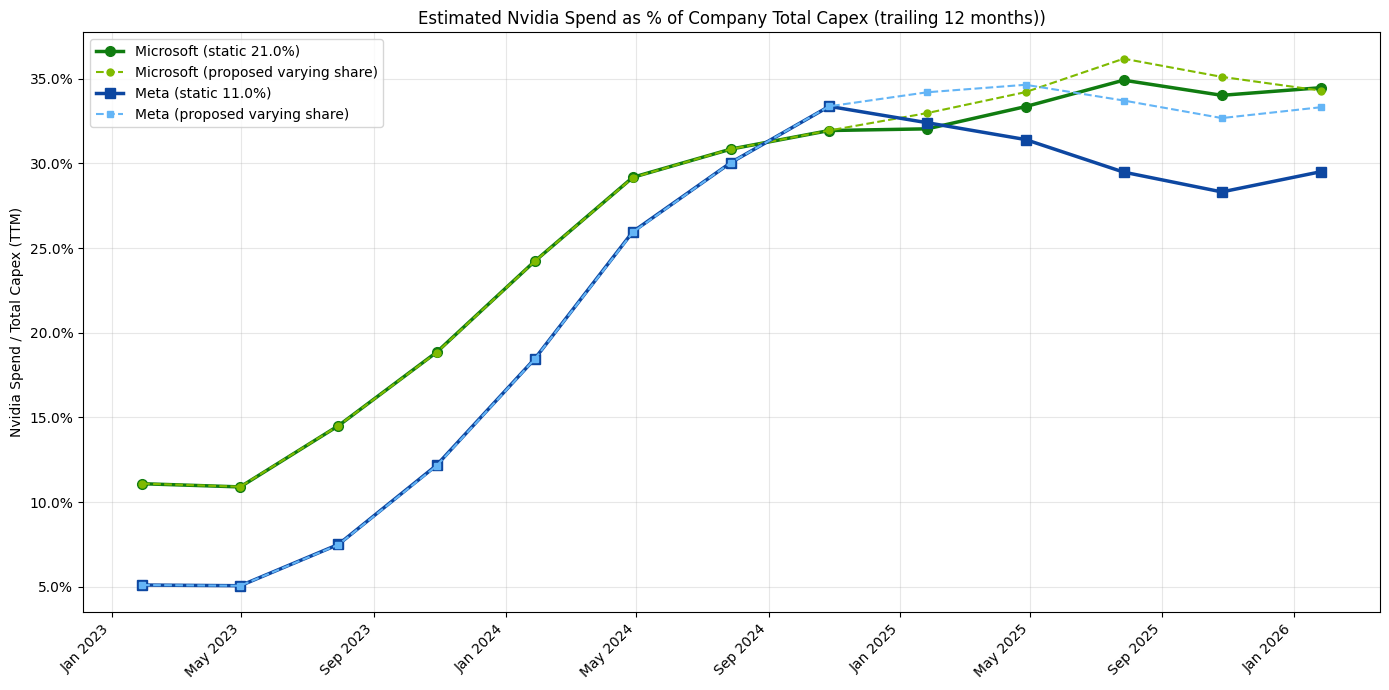

In [21]:
fig, ax = plt.subplots(figsize=(14, 7))

valid = df.dropna(subset=['msft_nvidia_pct_capex_ttm'])

ax.plot(valid['end_date'], valid['msft_nvidia_pct_capex_ttm'] * 100, 'o-',
        color=MSFT_COLOR, linewidth=2.5, markersize=7,
        label=f'Microsoft (static {MSFT_DC_SHARE:.1%})')
ax.plot(valid['end_date'], valid['msft_alt_nvidia_pct_capex_ttm'] * 100, 'o--',
        color=MSFT_ALT_COLOR, linewidth=1.5, markersize=5,
        label='Microsoft (proposed varying share)')
ax.plot(valid['end_date'], valid['meta_nvidia_pct_capex_ttm'] * 100, 's-',
        color=META_COLOR, linewidth=2.5, markersize=7,
        label=f'Meta (static {META_DC_SHARE:.1%})')
ax.plot(valid['end_date'], valid['meta_alt_nvidia_pct_capex_ttm'] * 100, 's--',
        color=META_ALT_COLOR, linewidth=1.5, markersize=5,
        label='Meta (proposed varying share)')

ax.set_ylabel('Nvidia Spend / Total Capex (TTM)')
ax.set_title('Estimated Nvidia Spend as % of Company Total Capex (trailing 12 months))')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Nvidia Spend as % of Capex (Quarterly)

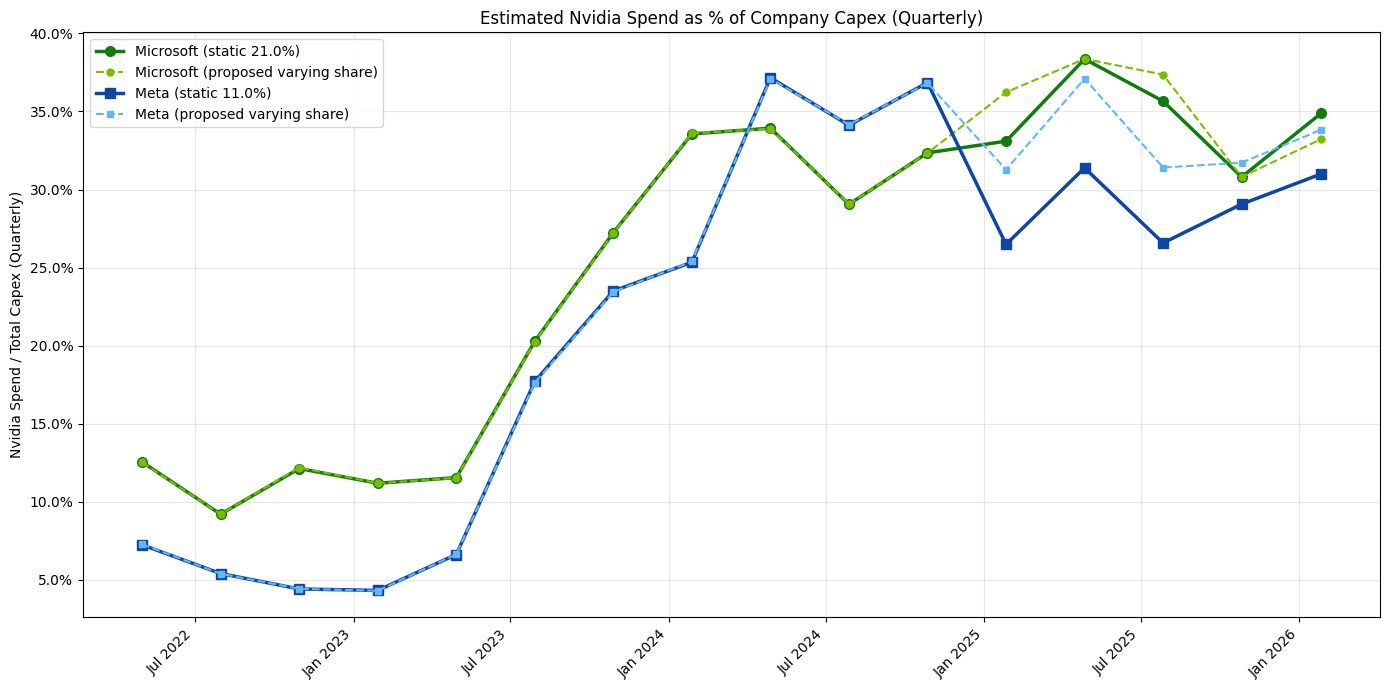

In [20]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df['end_date'], df['msft_nvidia_pct_capex'] * 100, 'o-',
        color=MSFT_COLOR, linewidth=2.5, markersize=7,
        label=f'Microsoft (static {MSFT_DC_SHARE:.1%})')
ax.plot(df['end_date'], df['msft_alt_nvidia_pct_capex'] * 100, 'o--',
        color=MSFT_ALT_COLOR, linewidth=1.5, markersize=5,
        label='Microsoft (proposed varying share)')
ax.plot(df['end_date'], df['meta_nvidia_pct_capex'] * 100, 's-',
        color=META_COLOR, linewidth=2.5, markersize=7,
        label=f'Meta (static {META_DC_SHARE:.1%})')
ax.plot(df['end_date'], df['meta_alt_nvidia_pct_capex'] * 100, 's--',
        color=META_ALT_COLOR, linewidth=1.5, markersize=5,
        label='Meta (proposed varying share)')

ax.set_ylabel('Nvidia Spend / Total Capex (Quarterly)')
ax.set_title('Estimated Nvidia Spend as % of Company Capex (Quarterly)')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()